In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Saves the dataset in drive for visibility across notebooks

In [ ]:
!ls

drive  sample_data


In [ ]:
import pandas as pd
import numpy as np

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix



In [ ]:
df = pd.read_csv("/content/drive/MyDrive/cleaned_spam_dataset.csv")
print(df.shape)
print(df.head())

(85777, 2)
                                       text_combined  label
0  fark rssfeedsspamassassintaintorg url URL NUMB...      0
1  alamac thanks painful got contract says NUMBER...      0
2  daily top NUMBER tanneryteunion NUMBER tnet da...      1
3  liza everett linpillardmetpillardde po dh ren ...      1
4  czanikhotmailcom font face NUMBER dverdana siz...      1


## TF-IDF Vectorization
To turn text into numeric features

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,     # keeping top 5000 words
    ngram_range=(1, 2),    # uni + bigrams
    stop_words='english'   # remove common stopwords
)

# build the vocab and convert each email into TF-IDF vector
X = vectorizer.fit_transform(df["text_combined"]) # number of emails x number of features
y = df["label"]

print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (85777, 5000)


In [ ]:
print(vectorizer.get_feature_names_out()[:20])


['__' '__ python' '__ pythondev' '_msgs' '_msgs number' '_nextpart_'
 '_nextpart_ number' 'aa' 'aa number' 'aaron' 'ab' 'ab number' 'abacha'
 'abidjan' 'ability' 'able' 'abroad' 'absolutely' 'abstract' 'abstracts']


### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("train size - ", X_train.shape[0])
print("test size - ", X_test.shape[0])

train size -  68621
test size -  17156


### Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

nb_model = MultinomialNB() # to create Naive Bayes model for word-count/TF-IDF data
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)

# evaluate
nb_acc = accuracy_score(y_test, nb_preds)
nb_prec, nb_rec, nb_f1, _ = precision_recall_fscore_support(y_test, nb_preds, average="binary")

print("Naive Bayes Results")
print(f"Accuracy:  {nb_acc:.3f}")
print(f"Precision: {nb_prec:.3f}")
print(f"Recall:    {nb_rec:.3f}")
print(f"F1-score:  {nb_f1:.3f}")


Naive Bayes Results
Accuracy:  0.955
Precision: 0.978
Recall:    0.932
F1-score:  0.954


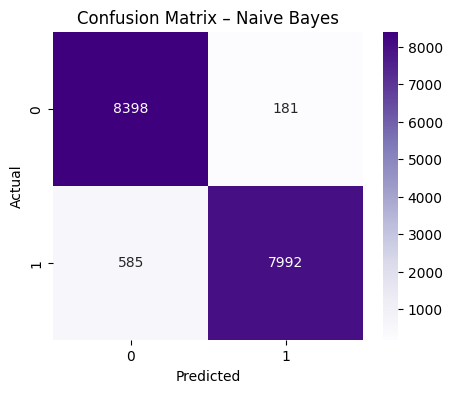

In [ ]:
# Compute confusion matrix
cm_nb = confusion_matrix(y_test, nb_preds)

# Visualize
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Naive Bayes')
plt.show()

### Logistic Regresaion Model

In [ ]:
lr_model = LogisticRegression(max_iter=500, n_jobs=-1)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(y_test, lr_preds, average="binary")

print("\nLogistic Regression Results")
print(f"Accuracy:  {lr_acc:.3f}")
print(f"Precision: {lr_prec:.3f}")
print(f"Recall:    {lr_rec:.3f}")
print(f"F1-score:  {lr_f1:.3f}")


Logistic Regression Results
Accuracy:  0.981
Precision: 0.979
Recall:    0.984
F1-score:  0.982


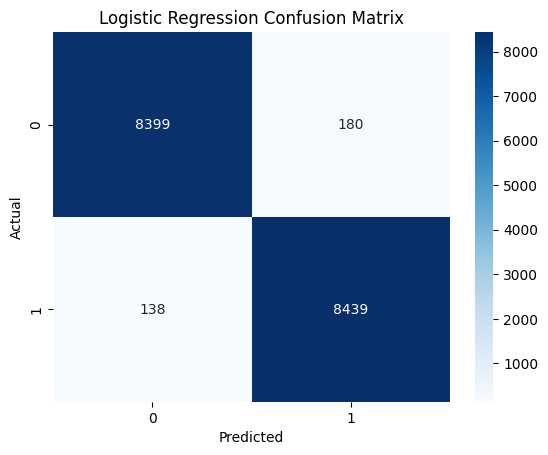

In [ ]:
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Save model in /models folder

In [ ]:
import os
import joblib

# uncomment when using .py file
# model_dir = os.path.join(os.getcwd(), "models")

# uncomment when using notebook
model_dir = "/content/drive/MyDrive/NLP_Spam_Project/models"
os.makedirs(model_dir, exist_ok=True)

# save Naive Bayes model
nb_path = os.path.join(model_dir, "naive_bayes_model.pkl")
joblib.dump(nb_model, nb_path)

# save Logistic Regression model
lr_path = os.path.join(model_dir, "logistic_regression_model.pkl")
joblib.dump(lr_model, lr_path)

print("Models saved successfully..")
print(" -", nb_path)
print(" -", lr_path)



Models saved successfully..
 - /content/drive/MyDrive/NLP_Spam_Project/models/naive_bayes_model.pkl
 - /content/drive/MyDrive/NLP_Spam_Project/models/logistic_regression_model.pkl


### Save TF-IDF vector

In [ ]:
# save TF-IDF Vectorizer for later use
vectorizer_path = os.path.join(model_dir, "tfidf_vectorizer.pkl")
joblib.dump(vectorizer, vectorizer_path)

print("TF-IDF vectorizer saved as: ", vectorizer_path)
